In [1]:
import sys
from pathlib import Path

# Add parent directory to Python path
parent_dir = Path.cwd().parent
sys.path.insert(0, str(parent_dir))

import pychnosz
_ = pychnosz.thermo("WORM")
from aqorg import Estimate#, Joback
import propfit
import pandas as pd

reset: thermodynamic system initialized
The WORM thermodynamic database has been loaded: 1713 aqueous, 2000 total species


In [2]:
pf = propfit.PropFit(filename='default_database_with_aq_props.csv', props=['Gh','Hh','Cph','V','Hig','Sig','Cpig','Gaq','Haq','Cpaq'])

In [3]:
pf.dataprep()

properties and groups.csv created


In [4]:
df = pd.read_csv('properties and groups.csv')
df.head()

,compound,Gh,Hh,Cph,V,Hig,Sig,Cpig,Gaq,Haq,...,C-[CX4H0R1!r3](-O)(-C)-O,O-[CX4H1R1r3](-C)-C,C-[CX4H1R1r3](-C)-C,C-[CX4H0R1r3](-C)(-C)-C,[CX4H2R1r3],C-[CX4H1R3r3](-C)-C,C-[CX4H0R3r3](-C)(-C)-C,C-[CX4H0R2r3](-[CX4H1R2r3])(-C)-C,C-[CX4H2R1!r3][cX3H0R2!r3][cH1],formula
0,Propane,16.090000,-22.926667,346.666667,70.90,-104.70,270.31,76.3,-8.22,-127.63,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3H8
1,n-Butane,16.580000,-25.925000,386.500000,75.55,-125.60,309.91,98.5,0.24,-151.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C4H10
2,n-Pentane,17.386000,-27.720000,452.000000,NaN,-146.75,349.56,120.0,8.75,-174.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C5H12
3,n-Hexane,16.962727,-31.470000,492.700000,NaN,-166.97,388.85,142.6,17.06,-198.44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C6H14
4,n-Heptane,18.354375,-36.186667,540.000000,NaN,-187.54,428.10,165.2,26.85,-223.73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C7H16


In [5]:
## where aqueous properties would be specified?
pf.group_property_estimator('properties and groups.csv', props = ['Gh','Hh','Cph','V','Hig','Sig','Cpig','Gaq','Haq','Cpaq'])

In [6]:
pf.generate()

IndexError: list index out of range

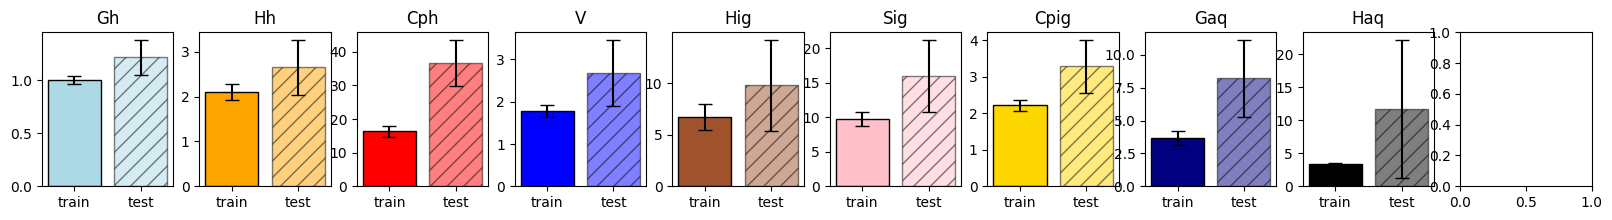

In [7]:
pf.tts()

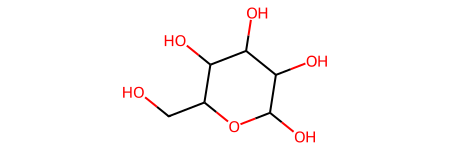

In [8]:
aq_props_gluc = Estimate(name="glucose", state="aq", aq_method="aqueous", aq_group_data="aq props.csv")

In [9]:
aq_props_gluc.Gaq, aq_props_gluc.Haq, aq_props_gluc.Saq, aq_props_gluc.Cpaq, aq_props_gluc.V

(-915.8997, -1262.1901, 272.5123, 363.0, 112.2)

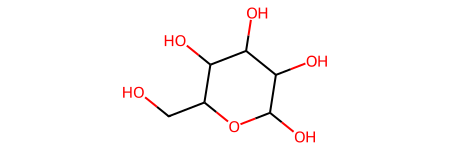

In [10]:
aq_props_gluc = Estimate(name="glucose", state="aq", aq_method="usual")

In [11]:
# Calculating glucose Gig from default database:

Hig = -1106.38*1000 # J/mol
Sig = 465.4 #J/mol/K
Selements = pychnosz.entropy("C6H12O6") #J/mol/K

Gig = Hig - 298.15*(Sig - Selements)
Gig/1000

np.float64(-817.5990655999999)

In [12]:
# CH2 group

Gig_actual = 9.05 - (0.68) # 8.37 kJ/mol

Hig = -20.63*1000 # J/mol
Sig = 39.16 #J/mol/K
Selements = pychnosz.entropy("CH2") #J/mol/K

Gig = Hig - 298.15*(Sig - Selements)

Gig/1000

np.float64(8.368069000000046)

NOT wrong for glucose:
- Selements (pychnosz.entropy("C6H12O6") matches CHNOSZ's output exactly)
- Gig calculation (the same equation used to calculate -492.24 kJ/mol exactly reproduced Gig for CH2 group from my dissertation)


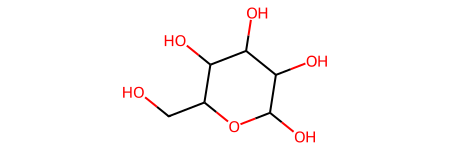

In [13]:
aq_props_gluc_original = Estimate(name="glucose", state="aq")

In [14]:
aq_props_gluc_original.Gig, aq_props_gluc_original.Gh

(np.float64(-776.97), -136.63000000000002)

In [15]:
aq_props_gluc_original.Gaq, aq_props_gluc_original.Haq, aq_props_gluc_original.Saq, aq_props_gluc_original.Cpaq, aq_props_gluc_original.V

(-913.6,
 -1301.0500000000002,
 np.float64(134.46233238302898),
 np.float64(nan),
 120.29)

In [16]:
import pandas as pd
df_Gaq = pd.read_csv("properties and groups regressed_Gaq.csv")
df_Gaq.head()

,compound,actual,prediction,pred errs
0,Propane,-8.22,-11.19,13.17
1,n-Butane,0.24,-1.82,13.18
2,n-Pentane,8.75,7.56,13.19
3,n-Hexane,17.06,16.93,13.20
4,n-Heptane,26.85,26.31,13.22


In [17]:
# lowerbenz = [v for v in df_Gaq['compound'] if "benzene" in v]
# upperbenz = [v for v in df_Gaq['compound'] if "Benzene" in v]
# benz = lowerbenz + upperbenz
# benz

In [18]:
# cyclos = [v for v in df_Gaq['compound'] if "Cyclo" in v]
# cyclos

In [19]:
# incomplete_matched_compounds = ["2-Methyl-1-propene", "2-Methyl-1,3-butadiene",
#                                 "2-Methyl-2-butene", "Propyne", "cumene", "Acetone",
#                                 "2-Butanone"] + benz + cyclos
# for c in incomplete_matched_compounds:
#     df_Gaq = df_Gaq[df_Gaq['compound'] != c]

In [20]:
df_Gaq["compound"]
# df_Gaq = df_Gaq.dropna(subset=["actual"])
df_Gaq.tail()

,compound,actual,prediction,pred errs
290,2-Cyclohexen-1-ol,NaN,-60.32,13.23
291,Cyclobutanol,NaN,-147.98,12.97
292,Cyclopentanemethanol,NaN,-116.56,13.16
293,2-Cyclopentylethanol,NaN,-107.19,13.18
294,2-Methyloctane,NaN,43.84,15.55


In [21]:
df_dd = pd.read_csv("default_database_with_aq_props.csv")

In [22]:
#store Estimate() output
aq_props_ig_hyd_list = []
aq_props_from_aq_list = []

for sp in df_Gaq["compound"]:

    sp_smiles_list = list(df_dd[df_dd["compound"]==sp]["SMILES"])
    assert len(list(set(sp_smiles_list)))==1 # check that each compound only has one unique smiles
    smiles = list(sp_smiles_list)[0]

    try:
        aq_props_ig_hyd = Estimate(name=sp, state="aq", smiles=smiles,
                        aq_method="default hyd + ig", ig_method="custom",
                        hyd_group_data="hyd props.csv",
                        ig_group_data="gas props.csv", show=False)
    
        aq_props_ig_hyd_list.append(aq_props_ig_hyd)
    except:
        aq_props_ig_hyd_list.append(None)

    try:
        aq_props_from_aq = Estimate(name=sp, smiles=smiles, state="aq", aq_method="aqueous", aq_group_data="aq props.csv", show=False)
        aq_props_from_aq_list.append(aq_props_from_aq)
    except:
        aq_props_from_aq_list.append(None)

In [23]:
Gaq_from_hyd_ig_list = []
Gaq_from_aq_list = []

for i,sp in enumerate(df_Gaq["compound"]):
    if aq_props_ig_hyd_list[i] != None:
        Gaq_from_hyd_ig_list.append(aq_props_ig_hyd_list[i].Gaq)
    else:
        Gaq_from_hyd_ig_list.append(float("NaN"))

    if aq_props_from_aq_list[i] != None:
        Gaq_from_aq_list.append(aq_props_from_aq_list[i].Gaq)
    else:
        Gaq_from_aq_list.append(float("NaN"))

In [24]:
df_Gaq['ig+hyd'] = Gaq_from_hyd_ig_list
df_Gaq['aq only'] = Gaq_from_aq_list

In [25]:
df_Gaq

,compound,actual,prediction,pred errs,ig+hyd,aq only
0,Propane,-8.22,-11.19,13.17,-9.0150,-11.1929
1,n-Butane,0.24,-1.82,13.18,-0.0981,-1.8170
2,n-Pentane,8.75,7.56,13.19,8.8188,7.5589
3,n-Hexane,17.06,16.93,13.20,17.7357,16.9348
4,n-Heptane,26.85,26.31,13.22,26.6526,26.3107
...,...,...,...,...,...,...
290,2-Cyclohexen-1-ol,NaN,-60.32,13.23,NaN,NaN
291,Cyclobutanol,NaN,-147.98,12.97,-112.7369,-147.9831
292,Cyclopentanemethanol,NaN,-116.56,13.16,-112.5238,-116.5625
293,2-Cyclopentylethanol,NaN,-107.19,13.18,-103.6069,-107.1866


In [26]:
df_Gaq.to_csv("Gaq_comparison.csv")

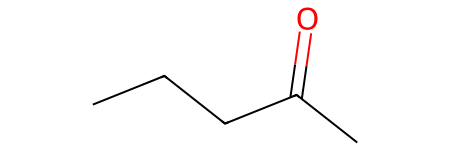

In [27]:
Estimate(name="2-Pentanone", state="hyd", hyd_group_data="hyd props.csv")

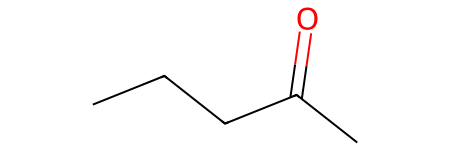

In [28]:
Estimate(name="2-Pentanone", state="gas", hyd_group_data="gas props.csv")

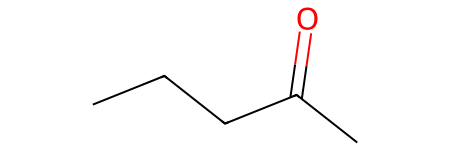

Exception: The formula of 2-Pentanone does not equal the the elemental composition of the matched groups. This could be because the database is missing representative groups.
Formula of 2-Pentanone:
{'C': 5.0, 'H': 10.0, 'O': 1.0}
Total formula of group matches:
{'C': 5.0, 'H': 10.0}
Incomplete group matches:
{'[C!H3]-[CX4H3R0]': 2, 'C-[CX4H2R0]-C': 2, 'C-[C](-C)=O': 1, 'C-[CH2]-C=O': 1}

In [29]:
Estimate(name="2-Pentanone", state="aq")

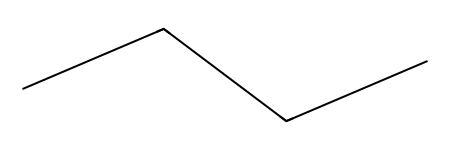

In [30]:
aq_props = Estimate(name="butane", state="aq", aq_method="aqueous", aq_group_data="aq props.csv")

In [31]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-1.817, -151.8996, 173.0, 475.3836, 80.633)

In [32]:
aq_props.Gaq_err

5.5332

In [33]:
aq_props.group_data.head()

,group,Gaq,Gaq_err,Gaq_n,Haq,Haq_err,Haq_n,Cpaq,Cpaq_err,Cpaq_n,V,V_err,V_n,elem
smarts,,,,,,,,,,,,,,
C-[CX4H2R1!r3]-C,C-[CX4H2R1!r3]-C,12.4589,1.6649,17,-47.8954,2.991,12,68.75,19.164,5,13.7174,0.6915,8,CH2
C-[CX4H1R1!r3](-C)-C,C-[CX4H1R1!r3](-C)-C,8.1672,4.4076,3,41.8474,7.4648,2,100.0445,47.9921,1,9.171,2.3644,3,CH
[CX3H2R0]=[C!H2],[CX3H2R0]=[C!H2],40.4232,5.8832,13,-54.3439,8.4992,9,102.9193,19.4257,5,11.4444,0.7959,5,CH2
C=[CX3H1R0]-C,C=[CX3H1R0]-C,48.777,2.4261,13,36.2926,2.7321,8,62.1745,36.4365,4,11.4444,0.7959,5,CH
C-[CX2H0R0]#N,C-[CX2H0R0]#N,98.4889,7.7325,1,24.9085,8.2777,5,3.1676,55.0383,2,16.054,1.7529,6,CN


In [34]:
-1.817*1000/4.184

-434.2734225621415

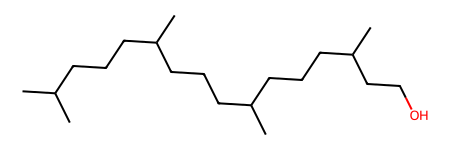

In [35]:
aq_props = Estimate(name="phytanol", state="aq", aq_method="aqueous", aq_group_data="aq props.csv")

In [36]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-15.3874, -747.0332, 507.704, 1736.2439, 334.0076)

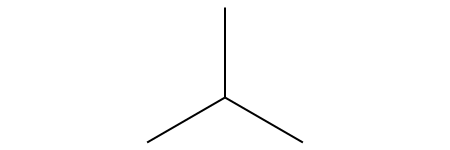

In [37]:
aq_props = Estimate(name="2-methylpropane", state="aq",
                    aq_method="default hyd + ig", ig_method="custom",
                    hyd_group_data="hyd props.csv",
                    ig_group_data="gas props.csv", round_sf=True)

In [38]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-2.6614000000000004,
 -156.78679999999997,
 np.float64(159.42087539829038),
 467.21580000000006,
 80.21620000000001)

In [39]:
# 2-methylpropane Gaq in default database: -3.33 kJ/mol

---

### loading hyd props and gas props CSVs and summing groups

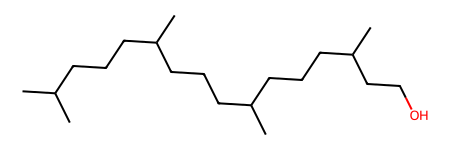

In [40]:
aq_props = Estimate(name="phytanol", state="aq",
                    aq_method="default hyd + ig", ig_method="custom",
                    hyd_group_data="hyd props.csv",
                    ig_group_data="gas props.csv", round_sf=True)

In [41]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-29.5909,
 -746.2512999999999,
 np.float64(557.9652403152813),
 1758.6686,
 334.0076)

---

### calculating gas properties first, then inputting them into Estimate()

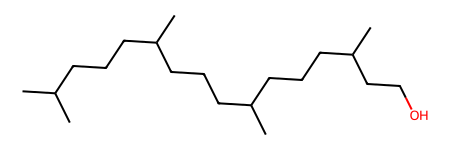

In [42]:
gas_props = Estimate(name="phytanol", state="gas", ig_method="custom", ig_group_data="gas props.csv", round_sf=False)

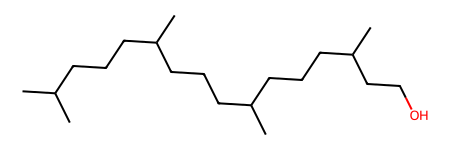

In [43]:
aq_props = Estimate(name="phytanol", state="aq", hyd_group_data="hyd props.csv", aq_method="default hyd + ig",
                    Gig = gas_props.Gig,
                    Hig = gas_props.Hig,
                    Sig = gas_props.Sig, 
                    Cpig = gas_props.Cpig,
                    round_sf=False,
                   )

In [44]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-29.5909,
 -746.2512999999999,
 np.float64(557.9652403152813),
 1758.6686,
 334.0076)